# Week 3: Topic Modeling & Entity Extraction

This notebook covers the complete Week 3 tasks:
1. **Topic Modeling (First Half)**: Ingesting datasets, training an LDA model, mapping topics to business labels, and plotting distribution by severity ratings.
2. **Named Entity Recognition (Second Half)**: Running spaCy NER on review texts to extract key entities, exporting the final dataset, and analyzing topic distribution by sentiment.

## Part 1: Topic Modeling (LDA)

### 1.1 Imports and Config

In [19]:
import os
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.corpora import Dictionary
from gensim.models import LdaModel

# Set relative paths from notebooks/ directory
labeled_data_path = '../outputs/labeled_dataset.csv'
cleaned_data_path = '../data/processed/reviews_cleaned.csv'
lda_model_dir = '../models/lda_model'
stage1_output_path = '../outputs/topics_stage1.csv'
fig_output_path = '../outputs/figures/topic_frequency.png'

print('Setup complete.')

Setup complete.


### 1.2 Ingest and Align Datasets

Load both `labeled_dataset.csv` and `reviews_cleaned.csv` and merge them on the review text column to bring back the preprocessed tokens.

In [35]:
df_label = pd.read_csv(labeled_data_path)
df_clean = pd.read_csv(cleaned_data_path)

# Inner join to match exact feedback texts
df_merged = pd.merge(
    df_label,
    df_clean[['feedback_text', 'tokens','feedback_topic']],
    left_on='review text',
    right_on='feedback_text',
    how='inner'
)

print(f'Original Labeled rows: {len(df_label)}')
print(f'Merged rows with tokens: {len(df_merged)}')
df_merged.head(2)

Original Labeled rows: 2500
Merged rows with tokens: 2500


,review text,rating,vader_label,distilbert_label,distilbert_confidence,rating_based_truth,feedback_text,tokens,feedback_topic
0,Our West India heavy machinery fabricator oper...,4,negative,positive,0.942185,positive,Our West India heavy machinery fabricator oper...,"['west', 'india', 'heavy', 'machinery', 'fabri...",pricing_commercial
1,Received 153 MT of Beams and Columns (PF Secti...,3,negative,negative,0.994328,neutral,Received 153 MT of Beams and Columns (PF Secti...,"['received', '153', 'mt', 'beam', 'column', 'p...",technical_compliance


### 1.3 Format Tokens

Parse the string-serialized token lists back to list of strings using `ast.literal_eval`.

In [21]:
df_merged['tokens_list'] = df_merged['tokens'].apply(ast.literal_eval)
print('First row tokens list sample:', df_merged['tokens_list'].iloc[0][:5])
print('Token lists count:', len(df_merged['tokens_list']))

First row tokens list sample: ['west', 'india', 'heavy', 'machinery', 'fabricator']
Token lists count: 2500


### 1.4 Create Document-Term Matrix

Build a Gensim dictionary and filter extreme values to omit rare and overly common tokens.

In [22]:
dictionary = Dictionary(df_merged['tokens_list'])

# Filter terms occurring in < 5 documents or > 50% of the documents
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Generate Bag of Words (BoW) corpus
corpus = [dictionary.doc2bow(text) for text in df_merged['tokens_list']]

print(f'Unique dictionary tokens count: {len(dictionary)}')
print(f'BoW corpus sample (first doc): {corpus[0][:10]}')

Unique dictionary tokens count: 2205
BoW corpus sample (first doc): [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1)]


### 1.5 Train LDA Topic Model

Train an LDA model with `num_topics=6` for `passes=10` with seed `random_state=42`.

In [23]:
num_topics = 6
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10
)

print('LDA Model trained successfully.')

LDA Model trained successfully.


### 1.6 Print Top 20 Topic Words

Inspect the top 20 words for each topic to understand their semantic meanings.

In [24]:
for idx in range(num_topics):
    words = [w[0] for w in lda_model.show_topic(idx, topn=20)]
    print(f'Topic {idx}: {words}')

Topic 0: ['transit', 'packaging', 'bundle', 'surface', 'material', 'plant', 'advance', 'site', 'arrived', 'dispatch', 'infrastructure', 'without', 'condition', 'damage', 'strapping', 'intimation', 'hessian', 'coil', 'rail', 'jindal']
Topic 1: ['dispatch', 'plant', 'day', 'rail', 'delivery', 'steel', 'transit', 'railway', 'material', 'logistics', 'lot', 'south', 'order', 'operation', 'arrived', 'quality', 'raigarh', 'angul', 'stockist', 'received']
Topic 2: ['plate', 'coil', 'hr', 'quality', 'surface', 'material', 'consistency', 'fabrication', 'jindal', 'cement', 'operation', 'across', 'without', 'performance', 'supply', 'construction', 'north', 'product', 'characteristic', 'stamping']
Topic 3: ['rebars', 'panther', 'jindal', 'tmt', 'technical', 'construction', 'strength', 'material', 'plant', 'engineer', 'quality', 'service', 'infrastructure', 'office', 'regional', 'structural', 'sale', 'grade', 'specification', 'complaint']
Topic 4: ['term', 'commercial', 'freight', 'payment', 'invoic

### 1.7 Map Exact Labels to Topics

Map topics to the exact human-readable labels:
- **Topic 0 $
ightarrow$ "packaging and handling"**: transit, packaging, bundle, strapping, hessian, damage
- **Topic 1 $
ightarrow$ "delivery and logistics"**: dispatch, delivery, railway, transit, logistics, delay
- **Topic 2 $
ightarrow$ "product and quality"**: plate, coil, hr, quality, surface, consistency, cement
- **Topic 3 $
ightarrow$ "customer service"**: technical sales, engineer site visits, complaints, service
- **Topic 4 $
ightarrow$ "pricing and commercial"**: commercial terms, payment terms, invoices, credit, GST
- **Topic 5 $
ightarrow$ "technical compliance"**: dimensional tolerances, structural specifications, section profiles

In [25]:
topic_mapping = {
    0: 'packaging and handling',
    1: 'delivery and logistics',
    2: 'product and quality',
    3: 'customer service',
    4: 'pricing and commercial',
    5: 'technical compliance'
}

print('Topic mapping configured.')

Topic mapping configured.


### 1.8 Assign Dominant Topics

Extract dominant topic index for each review and map to the business label.

In [39]:
def get_dominant_topic_label(bow):
    probs = lda_model.get_document_topics(bow)
    dominant = max(probs, key=lambda x: x[1])[0]
    return topic_mapping[dominant]

df_merged['topic_label'] = [get_dominant_topic_label(b) for b in corpus]
df_merged['topic_label'].value_counts()

topic_label
technical compliance      630
customer service          524
packaging and handling    386
delivery and logistics    383
product and quality       325
pricing and commercial    252
Name: count, dtype: int64

### 1.9 Save Trained LDA Model & Dictionary

Save the LDA model and dictionary to `models/lda_model/` so it can be reloaded later.

In [27]:
os.makedirs(lda_model_dir, exist_ok=True)
lda_model.save(os.path.join(lda_model_dir, 'lda_model'))
dictionary.save(os.path.join(lda_model_dir, 'lda_dict'))

print(f'Model and Dictionary saved in {lda_model_dir}')

Model and Dictionary saved in ../models/lda_model


### 1.10 Save Intermediate Dataset

Save columns to `outputs/topics_stage1.csv`.

In [28]:
output_columns = [
    'review text',
    'rating',
    'vader_label',
    'distilbert_label',
    'distilbert_confidence',
    'topic_label'
]

df_merged[output_columns].to_csv(stage1_output_path, index=False)
print(f'Intermediate dataset saved to {stage1_output_path}')

Intermediate dataset saved to ../outputs/topics_stage1.csv


### 1.11 Generate and Save Topic Frequency Chart by Truth Severity Ratings

Plot the frequency bar chart segmented by the ratings-based ground-truth sentiment (`rating_based_truth`) and save it to `outputs/figures/topic_frequency.png`.

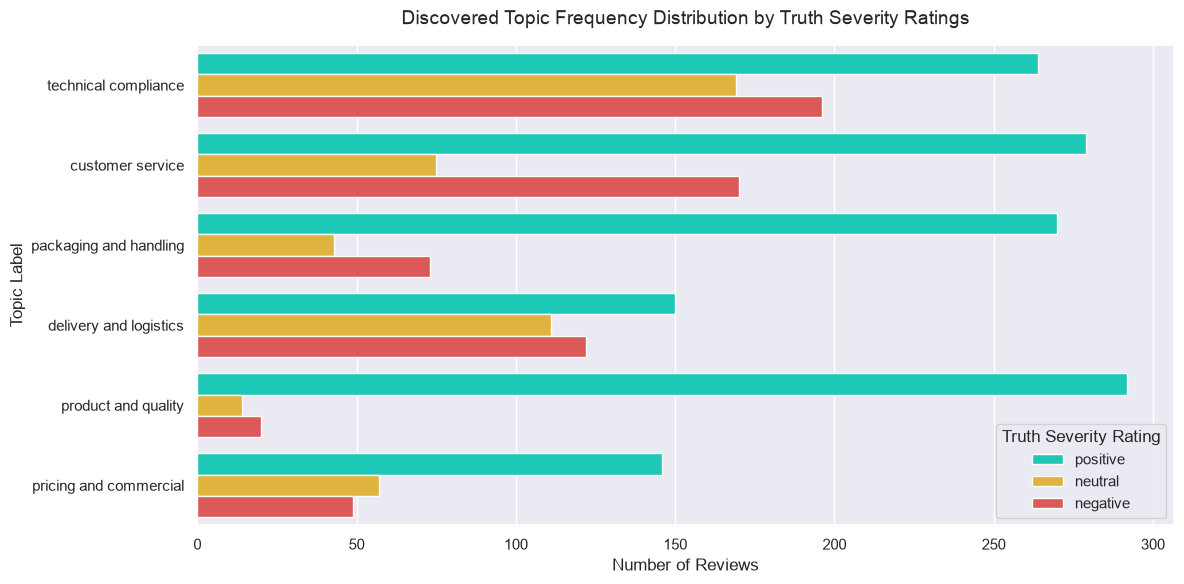

Topic frequency chart saved to ../outputs/figures/topic_frequency.png


In [29]:
plt.figure(figsize=(12, 6))
sns.set_theme(style='darkgrid')
order = df_merged['topic_label'].value_counts().index
ax = sns.countplot(
    data=df_merged,
    y='topic_label',
    hue='rating_based_truth',
    order=order,
    palette={'positive': '#00E5CC', 'neutral': '#FBBF24', 'negative': '#EF4444'}
)
plt.title('Discovered Topic Frequency Distribution by Truth Severity Ratings', fontsize=14, pad=15)
plt.xlabel('Number of Reviews', fontsize=12)
plt.ylabel('Topic Label', fontsize=12)
plt.legend(title='Truth Severity Rating', loc='lower right')
plt.tight_layout()

os.makedirs(os.path.dirname(fig_output_path), exist_ok=True)
plt.savefig(fig_output_path, dpi=150)
plt.show()

print(f'Topic frequency chart saved to {fig_output_path}')

## Part 2: Named Entity Recognition & Finalization

### 2.1 Load spaCy Model

Import spaCy and load the `en_core_web_sm` English language pipeline. Download it programmatically if it is not already available.

In [30]:
import spacy

# Load spacy model, downloading it if not present
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import subprocess
    import sys
    print('Downloading en_core_web_sm model...')
    subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'], check=True)
    nlp = spacy.load('en_core_web_sm')

print('spaCy model loaded successfully.')

spaCy model loaded successfully.


### 2.2 Define and Apply Entity Extraction Function

Extract all named entities from each review text using the loaded spaCy model.

In [31]:
def extract_entities(text):
    if pd.isna(text):
        return []
    doc = nlp(str(text))
    return [ent.text for ent in doc.ents]

df_merged['entities'] = df_merged['review text'].apply(extract_entities)
print('Extracted entities count:', df_merged['entities'].apply(len).sum())
df_merged[['review text', 'entities']].head()

Extracted entities count: 12473


,review text,entities
0,Our West India heavy machinery fabricator oper...,"[West India, 361, Billets, Blooms, Raigarh, Ra..."
1,Received 153 MT of Beams and Columns (PF Secti...,"[153, Beams, Columns, Angul, South India, third]"
2,Our chassis fabrication unit in Central India ...,"[Central India, 319, Beams, Columns, Angul]"
3,Round Bars procured for our Central India infr...,"[Round Bars, Central India, 704, MT, Patratu]"
4,Our dealership operations benefit tremendously...,"[JSL, Beams, 199, MT, Raigarh, West India]"


### 2.3 Save Final Merged Dataset

Export the complete dataset with sentiment labels, dominant topics, and extracted entities to `outputs/extracted_topics.csv`.

In [32]:
final_output_path = '../outputs/extracted_topics.csv'
df_merged.to_csv(final_output_path, index=False)
print(f'Final merged dataset saved to {final_output_path}')

Final merged dataset saved to ../outputs/extracted_topics.csv


### 2.4 Analyze Topic Distribution by Model Sentiments

Generate a cross-tabulation table and plot the topic distribution against predicted sentiment categories.

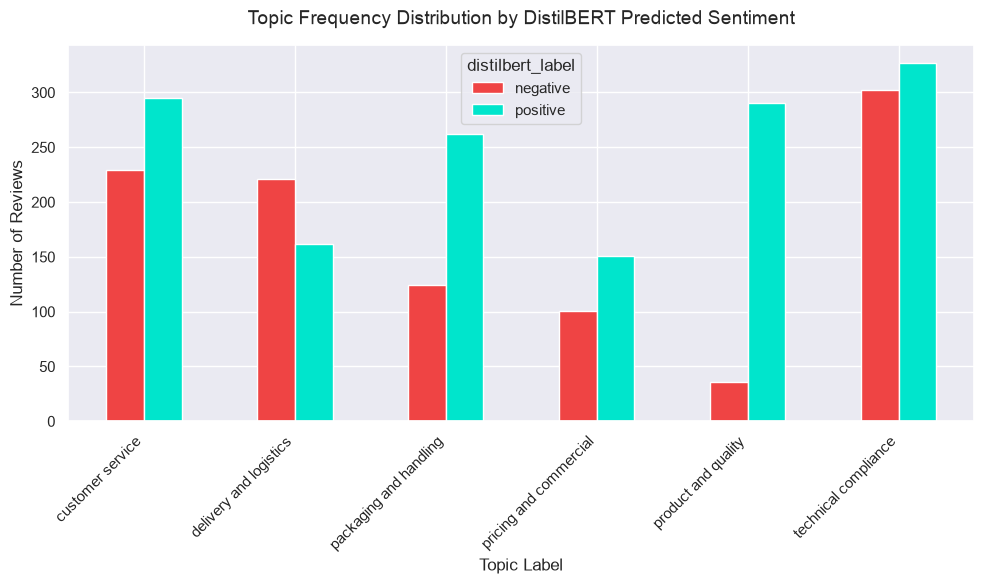

In [33]:
sentiment_topic = pd.crosstab(
    df_merged['topic_label'],
    df_merged['distilbert_label']
)

plt.figure(figsize=(10, 6))
sentiment_topic.plot(
    kind='bar',
    ax=plt.gca(),
    color=['#EF4444', '#00E5CC']
)
plt.title('Topic Frequency Distribution by DistilBERT Predicted Sentiment', fontsize=14, pad=15)
plt.xlabel('Topic Label', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/topic_sentiment_distribution.png', dpi=150)
plt.show()